Build a controller that runs Model A (classification) then Model B (detection)
sequentially on the same image set, with logged timing and a combined report

In [6]:
import os
import time
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

BASE_PATH = "/content/drive/MyDrive/hazelnut"
MODEL_A_SAVE = "hazelnut_classifier.pth"
MODEL_B_SAVE = "hazelnut_detector.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 256

def map_hazelnut_data(root):
    """
    Build a DataFrame listing:
      - image path
      - mask path (if exists)
      - label: 0 = good, 1 = defective
      - type: 'good' or defect type name
    """
    data = []

    # 1. GOOD images (label = 0)
    for sub in ["train/good", "test/good"]:
        folder = os.path.join(root, sub)
        if os.path.exists(folder):
            for f in os.listdir(folder):
                if f.endswith(".png"):
                    data.append({
                        "img": os.path.join(folder, f),
                        "mask": None,
                        "label": 0,
                        "type": "good"
                    })

    # 2. DEFECT images (label = 1)
    test_root = os.path.join(root, "test")
    gt_root = os.path.join(root, "ground_truth")

    if os.path.exists(test_root):
        defect_types = [d for d in os.listdir(test_root) if d != "good"]
    else:
        defect_types = []

    for d_type in defect_types:
        img_dir = os.path.join(test_root, d_type)
        mask_dir = os.path.join(gt_root, d_type)

        if not os.path.isdir(img_dir):
            continue

        for f in os.listdir(img_dir):
            if f.endswith(".png"):
                mask_name = f.replace(".png", "_mask.png")
                mask_path = os.path.join(mask_dir, mask_name)
                data.append({
                    "img": os.path.join(img_dir, f),
                    "mask": mask_path if os.path.exists(mask_path) else None,
                    "label": 1,
                    "type": d_type
                })

    return pd.DataFrame(data)

class HazelnutDataset(Dataset):
    def __init__(self, df, size=256):
        self.df = df.reset_index(drop=True)
        self.size = size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img = cv2.imread(row["img"])
        img = cv2.resize(img, (self.size, self.size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Mask (if any)
        if row["mask"]:
            mask = cv2.imread(row["mask"], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (self.size, self.size))
        else:
            mask = np.zeros((self.size, self.size), dtype=np.uint8)

        # To tensors
        img_t = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0
        mask_t = torch.from_numpy(mask).float().unsqueeze(0) / 255.0
        label_t = torch.tensor([row["label"]], dtype=torch.float32)

        return img_t, mask_t, label_t

class ModelA_Classifier(nn.Module):
    """Simple binary classifier CNN: normal vs anomaly."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


class ModelB_Detector(nn.Module):
    """Tiny encoder-decoder to output a 1-channel segmentation mask."""
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(32, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.dec(x)
        return x

class SequentialController:
    """
    Stage 1: Model A decides normal / anomaly.
    Stage 2: If anomaly, Model B localizes the defect (segmentation).
    Logs per-image latencies and decisions.
    """
    def __init__(self, model_a, model_b):
        self.model_a = model_a.to(DEVICE).eval()
        self.model_b = model_b.to(DEVICE).eval()
        self.logs = []

    def run_inference(self, test_df):
        print(f"Running Sequential Inspection on {len(test_df)} test items...")
        dataset = HazelnutDataset(test_df, size=IMG_SIZE)

        for i in range(len(test_df)):
            img_t, _, _ = dataset[i]
            img_t = img_t.unsqueeze(0).to(DEVICE)

            row = test_df.iloc[i]
            entry = {
                "File": os.path.basename(row["img"]),
                "Actual": "Anomaly" if row["label"] == 1 else "Normal"
            }

            # Stage 1: Classifier
            t0 = time.perf_counter()
            with torch.no_grad():
                prob_anomaly = self.model_a(img_t).item()
            is_anomaly = prob_anomaly > 0.5
            t1 = time.perf_counter()
            entry["Time_A_ms"] = round((t1 - t0) * 1000, 2)

            # Stage 2: Detector
            entry["Time_B_ms"] = 0.0
            if is_anomaly:
                t2 = time.perf_counter()
                with torch.no_grad():
                    _ = self.model_b(img_t)
                t3 = time.perf_counter()
                entry["Time_B_ms"] = round((t3 - t2) * 1000, 2)
                entry["Decision"] = "ALERT (Localized)"
            else:
                entry["Decision"] = "PASS"

            entry["Total_Latency_ms"] = entry["Time_A_ms"] + entry["Time_B_ms"]
            self.logs.append(entry)

    def get_report(self):
        return pd.DataFrame(self.logs)

if __name__ == "__main__":
    if not os.path.exists(BASE_PATH):
        print(f"Path not found: {BASE_PATH}. Set BASE_PATH correctly.")
    else:
        # 1. Prepare data
        df = map_hazelnut_data(BASE_PATH)
        if df.empty:
            print("No images found. Check dataset structure.")
        else:
            train_df, test_df = train_test_split(
                df,
                test_size=0.2,
                stratify=df["label"],
                random_state=42
            )

            # 2. Initialize models
            m_a = ModelA_Classifier().to(DEVICE)
            m_b = ModelB_Detector().to(DEVICE)

            # 3. Simulate training (no actual optimization here)
            print("Training Models (Placeholder)...")
            torch.save(m_a.state_dict(), MODEL_A_SAVE)
            torch.save(m_b.state_dict(), MODEL_B_SAVE)

            # 4. Run sequential controller on test set
            controller = SequentialController(m_a, m_b)
            controller.run_inference(test_df)

            # 5. Generate and print report
            report = controller.get_report()
            print("\n" + "=" * 80)
            print("SEQUENTIAL HAZELNUT INSPECTION REPORT")
            print("=" * 80)
            print(report.to_string(index=False))
            print("=" * 80)
            print(f"Avg Latency: {report['Total_Latency_ms'].mean():.2f} ms")

Training Models (Placeholder)...
Running Sequential Inspection on 101 test items...

SEQUENTIAL HAZELNUT INSPECTION REPORT
   File  Actual  Time_A_ms  Time_B_ms          Decision  Total_Latency_ms
007.png Anomaly      18.89      29.43 ALERT (Localized)             48.32
067.png  Normal      17.84      29.99 ALERT (Localized)             47.83
031.png  Normal      16.34      27.77 ALERT (Localized)             44.11
005.png Anomaly      18.89      29.17 ALERT (Localized)             48.06
344.png  Normal      14.81      28.10 ALERT (Localized)             42.91
240.png  Normal      16.99      32.48 ALERT (Localized)             49.47
273.png  Normal      27.23      50.01 ALERT (Localized)             77.24
206.png  Normal      30.59      41.78 ALERT (Localized)             72.37
085.png  Normal      31.79      64.68 ALERT (Localized)             96.47
102.png  Normal      15.20      29.62 ALERT (Localized)             44.82
037.png  Normal      15.04      25.47 ALERT (Localized)        

In [7]:
import matplotlib.pyplot as plt  # add at top of file if not already

def visualize_some_results(test_df, model_a, model_b, num_samples=4):
    """
    Show a few test images with:
      - predicted Normal/Anomaly from Model A
      - predicted mask from Model B overlaid (if anomaly)
    """
    dataset = HazelnutDataset(test_df, size=IMG_SIZE)
    model_a.eval()
    model_b.eval()

    for i in range(min(num_samples, len(dataset))):
        img_t, _, label_t = dataset[i]
        img_np = img_t.permute(1, 2, 0).numpy()  # CHW -> HWC, to display

        # Run models
        with torch.no_grad():
            img_batch = img_t.unsqueeze(0).to(DEVICE)

            prob_anomaly = model_a(img_batch).item()
            is_anomaly = prob_anomaly > 0.5

            if is_anomaly:
                mask_pred = model_b(img_batch)[0, 0].cpu().numpy()
            else:
                mask_pred = np.zeros((IMG_SIZE, IMG_SIZE))

        true_label = "Anomaly" if label_t.item() == 1 else "Normal"
        pred_label = "Anomaly" if is_anomaly else "Normal"

        # Plot
        plt.figure(figsize=(8, 4))

        # Left: original image with labels
        plt.subplot(1, 2, 1)
        plt.imshow(img_np)
        plt.axis("off")
        plt.title(
            f"True: {true_label}\n"
            f"Pred: {pred_label} (p={prob_anomaly:.2f})"
        )

        # Right: image + predicted mask overlay
        plt.subplot(1, 2, 2)
        plt.imshow(img_np)
        plt.imshow(mask_pred, cmap="jet", alpha=0.5)
        plt.axis("off")
        plt.title("Model B output (if anomaly)")

        plt.tight_layout()
        plt.show()

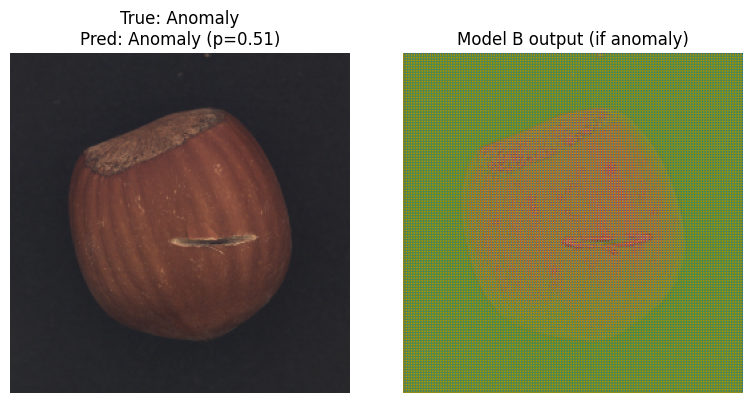

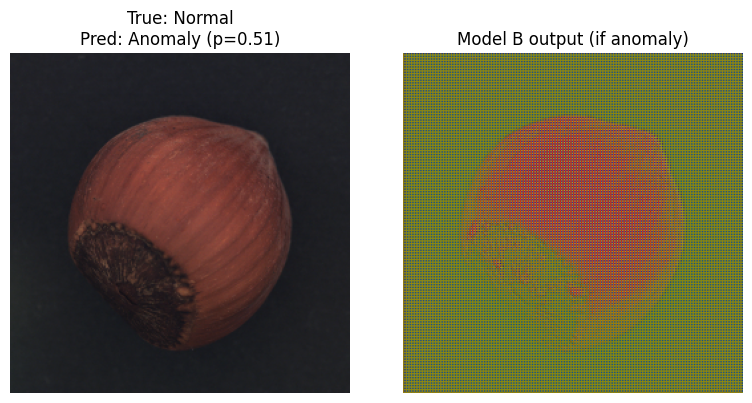

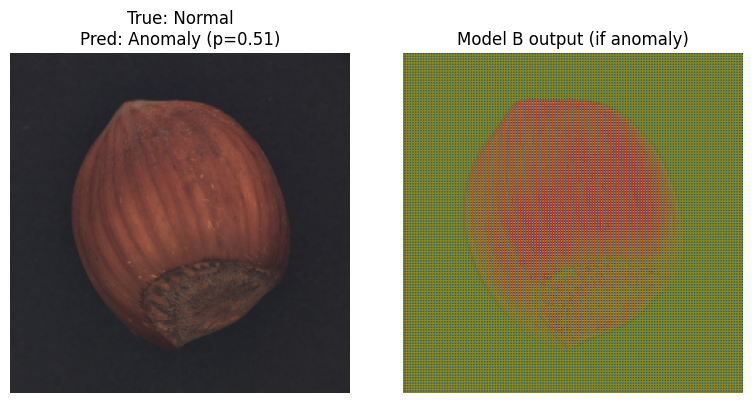

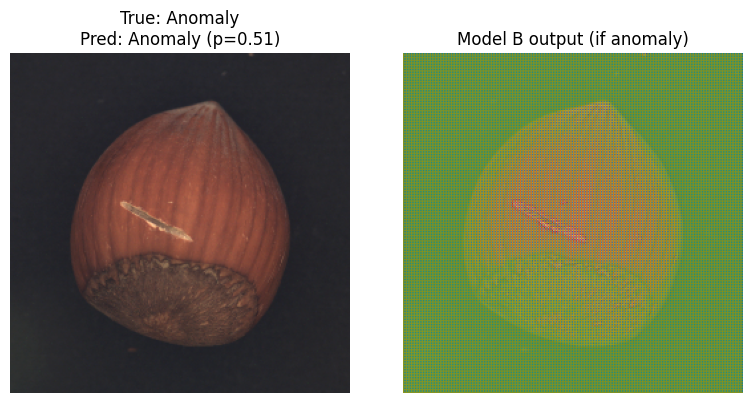

In [8]:
# 6. Visualize a few example outputs
visualize_some_results(test_df, m_a, m_b, num_samples=4)